# projeto da 1° Unidade de MLOPS
#### Aluno: Matheus Vinicius Silva Freire de Castro
##### Portflio: https://matheusdecastro.com/

este relatorio foi escrito dentro de um notebook jupyter para pode aprensentar tambem o codigo além da propria explicação do codigo, o .py -> [dag_feature_engineering.py](../../dags/dag_feature_engineering.py) contem o codigo que foi enviado para o airflow, e tambem pode ser acessado com mais detalhes dentro do repositorio: https://github.com/Matheus-dCastro/MLOPS, alem dos outros arquivos que fazem parte dessa atividade


#### **Qual API foi utilizada?**
foi utilizada para fazer esse laboratorio a ali  TMDB:  https://www.themoviedb.org/settings/api

#### **Que tipo de dados ela fornece?**
ela forneceu dados modelados em json, contendo o nome, sinops do filme, popularidade, clasificado apenas com adutlado ou não devido ser apenas um dado booleando que todos estavam como falso foi removido do df final, data de lançamento, avaliação, capas, video, titulo, genreos por ID, idioma todos com o retorno sendo string dando a possibilidae de poder extrair no idioma desejado
#### **Por que essa fonte foi escolhida?** 
Esta api foi escolhida pela requisa de fontes e detalhes permitindo varios tipos de analise seja pelas imagens dos filmes que ela pode devolver e ate pelos dados categoricos que ela devolve.

#### **Quais features foram produzidas e com quais técnicas?**
foi desenvolvido:
- age (IDADE): Que foi usado apenas a data de lançamento do filme e a data atual, essa feature pode ser usada para criar saber o quanto esse filme envelheceu bem ou mal na avaliação do publico
- num_genres (numero de generos): conta quantos generos um filme tem pode ser usado para saber a relação tantos generos possibilitou um filme se sair melhor ou pior
- para cada tipo de genero foi criado um uma feature unica para ele e em caso do filme ter um determinado genero ou não sera colocado 1 com contem o genero e 0 com o não contem possibilitando o modelo trabalhar ja em uma escala normalizada 
- overview_count (contar quantatas palavras tem na sinops de cadas filme): qual seria uma boa relação no numero de palavras escritas quanto impactou para que tenha um numero de votos alta ou baixa não subistitui a necessidade do modelo analisar o contexto do que esta escrito e avaliar o qual bem foi capitado pelo o publico esse tipo de descrição

#### **Por que essas técnicas são adequadas aos dados?** 
Por que permiti multiplas analise de forma diferentes e eficiente para diversos tipos de tecnicas, formas de aprendizado e de objetivos e avaliações.

![Screenshot from 2026-09-17 20-43-14.png](<attachment:Screenshot from 2026-09-17 20-43-14.png>)

### API/Extract

explicando como está o fluxo, ele começa fazendo a requisição para api enviado qual o tipo de requisição sendo tanto a para extrair os filmes essa contendo o numero de filme que queremos (num_pages = 5 e para cada pagina tem 20 filmes) caso o numero de paginas seja informado vai enviar tambem que quer os dados literais em PT-BR mas tambem devolve a lingua de origem do filme, e tambem é enviado o de requisição dos id por genero, na requisição para receber os filmes ele n devolve os generos descritos e sim os ids de cada filme ligados ao bando de dados assim foi necessario fazer uma outra requisição para poder obter o que cada id representa qual genero 

### Transforme

aqui acontece o processo de montar o df, tanto relacionado cada id a um genero escrito de forma literal quanto a remoção de features descessarias como: "release_date","genre_ids","backdrop_path","poster_path","softcore","video","adult","original_title" quanto a normalização de algumas novas features como ja descrito acima quanto a normalização da feature "vote_count","popularity" e retorna a o df formado mas ainda não esta criado o df na pasta data.

#### **Como o DAG foi executado e como você verificou o resultado? Quais informações dos logs foram úteis?**

foi agendado com @daily (data de início em 17/09/2026, com catchup=False), mas seu teste e validação foram realizados via trigger manual diretamente pela UI do Airflow (ou comando airflow dags trigger dag_feature_engineering).A passagem de parâmetros sensíveis e de volume (URL, URL_GEN, KEY, pagues) foi isolada nas Airflow Variables, permitindo ajustes sem alteração no código-fonte.

Verificação do Resultado: todos as tasks foram aprovadas com sucesso dentro e fora do airflow.


#### **Quais são os principais benefícios do Apache Airflow para o gerenciamento de pipelines de Machine Learning? Considere aspectos como automação, dependências entre tarefas, agendamento, monitoramento, logs, reexecução e escalabilidade**

- Automação e Agendamento Preciso (Scheduling): Permite disparar rotinas de extração de dados, extração em lote com base em cronograma fixo (@daily, @weekly) como foi aqui mesmo, no dia 12 desse mes o top filme era o ultimo filme de avatar a lenda de ange porém hoje dia 17 com o ultimo teste o filme mais bem avaliado foi o ultimo lançamento do batman ou disparos orientados a eventos eliminou de certa forma a necessidade de intervenções manuais.

- Observabilidade e Logs Centralizados: Centraliza a visualização gráfica de execuções históricas e armazena logs detalhados por tarefa.

#### **Quando seria mais apropriado utilizar um fluxo ETL e quando seria mais apropriado utilizar ELT? Relacione sua resposta com onde ocorre a transformação, capacidade de processamento, armazenamento dos dados, flexibilidade do pipeline e contexto de utilização.**
##### ETL: 
Quando dados sensíveis não podem, sob hipótese alguma, ser persistidos em seu estado original no repositório final sem antes passarem por anonimização, mascaramento ou hashing. ou Quando o volume bruto gerado por APIs é massivo, mas apenas uma fração agregada é mantida não sendo bem nosso caso por que mesmo que parte delea não serviu para composição final esses dados ainda ajudaram a construir a ideia do que poderia e o que deveria ser feito.
##### ELT:
Ambientes em nuvem baseados em computação distribuída e colunar, onde o motor de consulta foi projetado especificamente para transformar petabytes em segundos.Projetos modernos de Machine Learning para cientistas de dados que frequentemente precisam explorar hipóteses e derivar novas variáveis que não haviam sido previstas no design inicial do pipeline. Ter os dados brutos sempre acessíveis permite reprocessar features e gerar novos datasets de treino retroativamente.

#### **Quais foram as principais dificuldades encontradas para instalar e executar o Airflow? Como você resolveu esses problemas?**

para fazer a instalação eu simplesmente usei um ambiente virtual do python usando o comando avp, como usuo zsh crie esse comando que ja lista e cria um venv com dependecias pre instaladas assim com o gitignore e ouras coisas alem disso bastou no final eu instalar o airflow no ambiente. A dificuldade maior foi efeturar o login, por que optei por mudar a senha no json de config do airflow para uma senha mais simples que eu pudesse decorar.

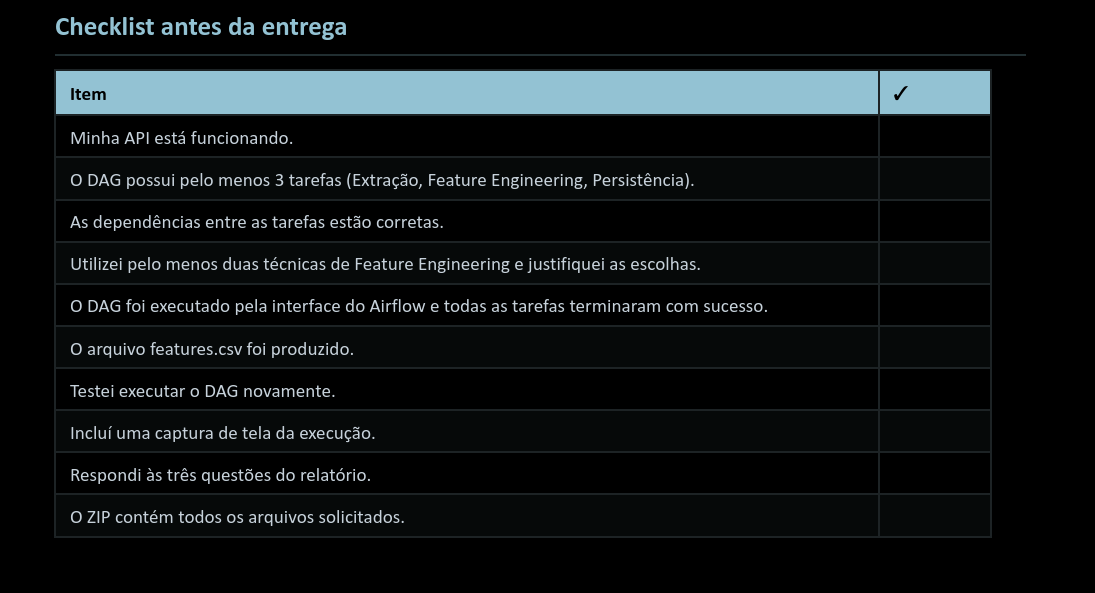
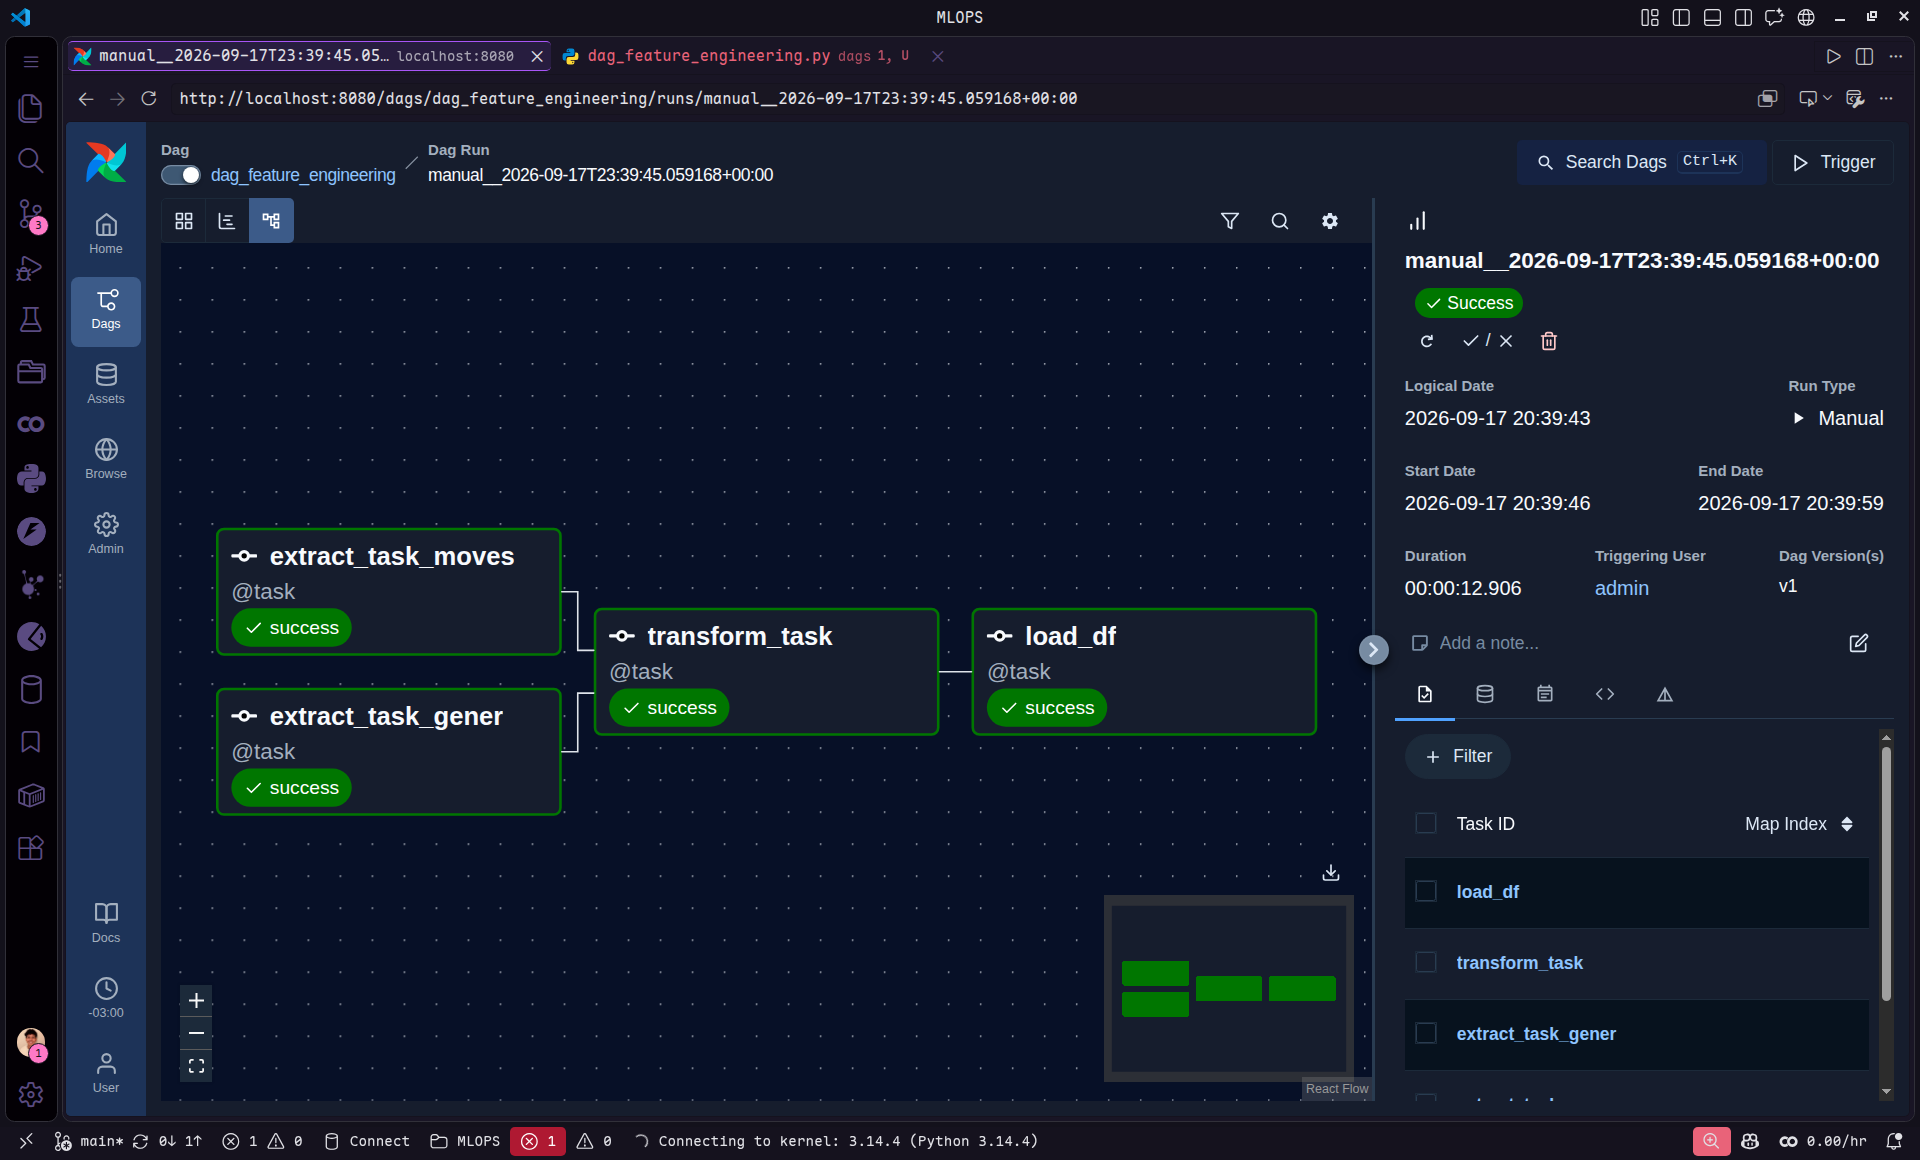

In [10]:
# Imports
from airflow.providers.standard.operators.empty import EmptyOperator
from airflow.decorators import task
from airflow.models import Variable
from airflow import DAG

import requests

from datetime import datetime

from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

import os


2026-09-18T01:41:39.348652Z [warning  ] The `airflow.decorators.task` attribute is deprecated. Please use `'airflow.sdk.task'`. [py.warnings] category=DeprecatedImportWarning filename=/tmp/ipykernel_8595/2867945656.py lineno=3


Aqui foi colocado todos os links para requisião e uma chave de api para teste momentania

In [ ]:
# links pra fazer a requisição e a chave da api do airflow

URL = Variable.get(key="URL", "https://api.themoviedb.org/3/movie/top_rated")
URL_GEN= Variable.get("URL_GEN", "https://api.themoviedb.org/3/genre/movie/list")
API_KEY = Variable.get("KEY", "66f326ea45d4f51ff3ed4071d5f20ad0") 
pagues = int(Variable.get("pagues", 5)) # o numero 5 em pages ira devolver os 100 primeiros filmes sendo 20 para cada page


Função generica q permite fazer a requisiçao tanto dos filmes quanto do genero dos filmes

In [ ]:
def api_request(URL="", api_key="", n_pages=None): # requisição função generica q permite fazer a requisiçao tanto dos filmes quanto do genero dos filmes
    parametros = {
        "api_key": api_key,
        "language": "pt-BR",
    }
    if n_pages is not None:https://matheusdecastro.com/
        parametros["page"] = n_pages

    result = requests.get(url=URL, params=parametros)
    if (result.status_code == 200):
        dados = result.json()
        return dados
    else:
        print(f"ERROR: {result.status_code}" )

print(api_request(URL, API_KEY))

{'page': 1, 'results': [{'adult': False, 'backdrop_path': '/caBIySpwuFi2i7ynvHIlnxJLOdN.jpg', 'genre_ids': [16, 28, 12, 878], 'id': 1560520, 'title': 'Batman: A Queda do Morcego - Parte 1', 'original_language': 'en', 'original_title': 'Batman: Knightfall Part 1: Knightfall', 'overview': 'O Asilo Arkham foi destruído, e todos os seus detentos foram soltos em Gotham City. Enquanto corre contra o tempo para capturar alguns de seus maiores inimigos, Batman é levado ao limite de suas capacidades físicas e mentais, rumo a um confronto final contra uma nova ameaça: o homem chamado Bane!', 'popularity': 82.3541, 'poster_path': '/qJJTWt69ZUxFQU0SUh0dWN9bUqf.jpg', 'release_date': '2026-06-23', 'softcore': False, 'video': False, 'vote_average': 9.18, 'vote_count': 323}, {'adult': False, 'backdrop_path': '/ezbrL1dMymKQZw7mDEWa2ZTzN7d.jpg', 'genre_ids': [16, 12, 14, 28], 'id': 980431, 'title': 'Avatar Aang: O Último Mestre do Ar', 'original_language': 'en', 'original_title': 'Avatar Aang: The Last 

Aquie é apenas a etapa de criar as task ela está melhor descrita no codigo

In [ ]:

@task   
def extract_task_moves(URL,API_KEY, pages=0 ): # extração dos filmes mais bem avaliados
    all_moves = []
    
    for page in range(1, pages+1):
        requisicao = api_request(URL, API_KEY , str(page))
        if(requisicao and "results" in requisicao):
            all_moves.extend(requisicao["results"])
    return all_moves


@task   
def extract_task_gener(API_KEY, URL): # extraçao 
    id_generos= api_request(URL, API_KEY) # estrai da api o genero de cada filme relacionado a cada id
    genres = []
    if(id_generos and "genres" in id_generos):
        genres.extend(id_generos["genres"])
    return genres


@task 
def transform_task(moves, geners):
    df_all_moves =  pd.DataFrame(moves)
    
    os.makedirs("data", exist_ok=True)
    df_all_moves = df_all_moves.sort_values(by="vote_average", ascending=False) # ordena pela quanntidade de aprovação do filme pelo piblico

    df_all_moves["age"] =  datetime.now().year - pd.to_datetime(df_all_moves["release_date"]).dt.year # feature: pega a data de lançamento do filme e passa ela para quantos anos ele foi lançado

    mapa_generos = {g["id"]: g["name"] for g in geners} # feature: mapea quais os genereos em cada filme e associa as features criadas no proximo passo

    for id_g, nome_g in mapa_generos.items(): # feature
        coluna = f"genero_{nome_g.lower().replace(' ', '_')}"
        df_all_moves[coluna] = df_all_moves["genre_ids"].apply(lambda ids: 1 if id_g in ids else 0)
        
    df_all_moves["num_genres"] = df_all_moves["genre_ids"].apply(len) # feature: quantos genereos tem cada filme 
    
    df_all_moves =  df_all_moves.drop(["release_date","genre_ids","backdrop_path","poster_path","softcore","video","adult","original_title"],axis=1) # remove featores desnecessarias para analise

    scaler = StandardScaler()
    colunas_para_normalizar = ["vote_count","popularity"] 
    df_all_moves[colunas_para_normalizar] = scaler.fit_transform(df_all_moves[colunas_para_normalizar]) # normaliza as colunas com mais influencia para um modelo poder analizar
    
    df_all_moves["overview_count"] = df_all_moves["overview"].fillna("").astype(str).str.strip().apply(len) # conta quantas palavras tem em cada sinopse de cada filme
    
    df_all_moves["overview"] = df_all_moves["overview"].replace(" ", np.nan).fillna(" ") # seria para remover o miss valeu e passar a ter um espaço em branco porem não deu certo
    
    return df_all_moves # retorna o dataset montado


@task   
def load_df(df:pd.DataFrame, name_df="features"): # cria o arquivo csv
    df.to_csv(f"data/{name_df}.csv", index=False)
    return df


In [16]:

with DAG(
        dag_id="dag_feature_engineering",
        start_date=datetime(2026, 9, 17),
        schedule="@daily",
        catchup=False
    ) as dag:
    filmes = extract_task_moves(URL, API_KEY, pagues) 
    generos = extract_task_gener(API_KEY, URL_GEN)
    df = transform_task(filmes, generos)
    load_df(df)


df.head()



,id,title,original_language,overview,popularity,vote_average,vote_count,age,genero_ação,genero_aventura,...,genero_música,genero_mistério,genero_romance,genero_ficção_científica,genero_cinema_tv,genero_thriller,genero_guerra,genero_faroeste,num_genres,overview_count
0,1560520,Batman: A Queda do Morcego - Parte 1,en,"O Asilo Arkham foi destruído, e todos os seus ...",2.092680,9.180,-0.874362,0,1,1,...,0,0,0,1,0,0,0,0,4,297
1,980431,Avatar Aang: O Último Mestre do Ar,en,"O Avatar Aang, o último mestre do ar do mundo,...",2.304084,9.140,-0.796002,0,1,1,...,0,0,0,0,0,0,0,0,4,301
2,1007757,Como Mágica,en,Uma pequena criatura da floresta e um pássaro ...,0.427058,8.869,-0.695967,0,0,1,...,0,0,0,0,0,0,0,0,4,146
3,1632181,Socias por accidente,es,,-0.453210,8.850,-0.868799,0,0,0,...,0,0,1,0,0,0,0,0,2,0
4,1621552,A Captura,es,Dois policiais mexicanos precisam sobreviver à...,3.372887,8.814,-0.838107,0,1,0,...,0,0,0,0,0,1,0,0,3,132


Para finalizar o arquivo [pipelin.py](pipeline.py) foi a onde eu estava executando os primeitos testes e o desevolvimento inicial desse laboratorio caso chegue a verificar os logs de commits e o arquivo que foi iniciado dia 12 encontrará a linha do tempo desse pequeno projeto.
